# Baseline Model: Linear Regression

This notebook implements the project baseline model for **national electricity demand forecasting** using:
- lagged demand features (autoregressive signal)
- socio-economic features (`gdp`, `population`, `gdp_per_capita`)

**Target:** `electricity_demand` (TWh)  
**Train/Test split:** Train = 2003-2019, Test = 2020-2023  
**Metrics:** RMSE and MAE

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [19]:
# Load dataset
DATA_PATH = 'df_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()}-{df.year.max()}')
df.head()

Loaded: df_clean.csv
Shape: 6994 rows x 18 columns
Countries: 181
Year range: 1985-2024


,country,year,population,iso_code,gdp,biofuel_electricity,coal_electricity,electricity_demand,electricity_generation,fossil_electricity,gas_electricity,greenhouse_gas_emissions,hydro_electricity,nuclear_electricity,oil_electricity,renewables_electricity,solar_electricity,wind_electricity
0,American Samoa,1985,39128.0,ASM,6.040371e+08,0.0,0.0,0.078,0.078,0.078,NaN,0.018,0.0,0.0,NaN,0.0,0.0,0.0
1,American Samoa,1986,40588.0,ASM,6.894330e+08,0.0,0.0,0.084,0.084,0.084,NaN,0.024,0.0,0.0,NaN,0.0,0.0,0.0
2,American Samoa,1987,42095.0,ASM,7.549983e+08,0.0,0.0,0.090,0.090,0.090,NaN,0.030,0.0,0.0,NaN,0.0,0.0,0.0
3,American Samoa,1988,43634.0,ASM,7.891841e+08,0.0,0.0,0.096,0.096,0.096,NaN,0.036,0.0,0.0,NaN,0.0,0.0,0.0
4,American Samoa,1989,45207.0,ASM,8.419489e+08,0.0,0.0,0.102,0.102,0.102,NaN,0.042,0.0,0.0,NaN,0.0,0.0,0.0


In [20]:
# Feature engineering
TARGET = 'electricity_demand'
LAGS = [1, 2, 3]

df = df.sort_values(['country', 'year']).reset_index(drop=True)

for lag in LAGS:
    df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)

# Lagged year-over-year change (no leakage): (t-1) - (t-2)
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)

# Exogenous interaction
df['gdp_per_capita'] = df['gdp'] / df['population']

FEATURE_COLS = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita'
]

df_model = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Usable rows after lag features: {len(df_model)}')
df_model[['country', 'year'] + FEATURE_COLS + [TARGET]].head()

Usable rows after lag features: 6451


,country,year,demand_lag1,demand_lag2,demand_lag3,demand_yoy_change,gdp,population,gdp_per_capita,electricity_demand
3,American Samoa,1988,0.090,0.084,0.078,0.006,7.891841e+08,43634.0,18086.449396,0.096
4,American Samoa,1989,0.096,0.090,0.084,0.006,8.419489e+08,45207.0,18624.303326,0.102
5,American Samoa,1990,0.102,0.096,0.090,0.006,8.735035e+08,46659.0,18721.008140,0.108
6,American Samoa,1991,0.108,0.102,0.096,0.006,9.136560e+08,47903.0,19073.043107,0.114
7,American Samoa,1992,0.114,0.108,0.102,0.006,9.605524e+08,49054.0,19581.530228,0.120


This cell is doing feature engineering: it creates the input variables the linear regression will use to predict electricity demand. The main idea is that current demand is strongly related to recent past demand, so the code builds lag features to give the model that history.

What each part is doing in baseline_model.ipynb:
1. `TARGET = 'electricity_demand'` sets the column you want to predict.
2. `LAGS = [1, 2, 3]` says you want to use demand from 1 year ago, 2 years ago, and 3 years ago as predictors.
3. `df = df.sort_values(['country', 'year'])` is necessary so “previous year” actually means the correct previous record within each country.
4. The loop
   ```python
   for lag in LAGS:
       df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)
   ```
   creates new columns:
   - `demand_lag1`: previous year’s demand
   - `demand_lag2`: demand from 2 years ago
   - `demand_lag3`: demand from 3 years ago

How `shift(lag)` works:
1. Within each country, it moves the target column downward by `lag` rows.
2. So for a row like India in 2018:
   - `demand_lag1` becomes India 2017 demand
   - `demand_lag2` becomes India 2016 demand
   - `demand_lag3` becomes India 2015 demand
3. The first few years for each country become `NaN` because there is no earlier history available.

Why lags are needed:
1. Electricity demand is usually autocorrelated, meaning this year depends heavily on recent previous years.
2. A plain linear regression does not remember history by itself, unlike some time-series models. You have to explicitly give it past values as inputs.
3. Lags let the model capture momentum, persistence, and recent trend without using future information.
4. They are especially useful in forecasting because past demand is often one of the strongest predictors of future demand.

Why this is safe for forecasting:
1. A lag uses only past values, not current or future values.
2. That avoids target leakage.
3. For example, using 2019 demand to predict 2020 is valid; using 2021 demand to predict 2020 would be leakage.

The year-over-year change line:

```python
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)
```

This adds another history-based feature:
1. `diff()` computes the change from one year to the next.
2. `shift(1)` moves it back so the model only sees past change, not current-year change.
3. Conceptually, this feature tells the model whether demand had been increasing or decreasing recently.

Why `dropna(...)` is needed:
1. The first few rows per country have missing lag values.
2. Regression models can’t train on missing inputs here.
3. So `df_model = df.dropna(...)` keeps only rows where all lag and feature columns exist.

In short, the lag features turn a normal regression model into a simple forecasting model by giving it short-term memory. Without them, the model would only rely on GDP and population-like variables and would miss a large part of the time dependence in electricity demand.

If you want, I can also explain this cell with a small concrete example table for one country over 5 years.

```python
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)
```

This adds another history-based feature:
1. `diff()` computes the change from one year to the next.
2. `shift(1)` moves it back so the model only sees past change, not current-year change.
3. Conceptually, this feature tells the model whether demand had been increasing or decreasing recently.

Why `dropna(...)` is needed:
1. The first few rows per country have missing lag values.
2. Regression models can’t train on missing inputs here.
3. So `df_model = df.dropna(...)` keeps only rows where all lag and feature columns exist.

In short, the lag features turn a normal regression model into a simple forecasting model by giving it short-term memory. Without them, the model would only rely on GDP and population-like variables and would miss a large part of the time dependence in electricity demand.

If you want, I can also explain this cell with a small concrete example table for one country over 5 years.


In [21]:
# Temporal train/test split
TRAIN_END = 2019
TEST_START = 2020

train = df_model[df_model['year'] <= TRAIN_END].copy()
test = df_model[df_model['year'] >= TEST_START].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f'Train rows: {len(train)}')
print(f'Test rows: {len(test)}')
print(f'Features: {FEATURE_COLS}')

Train rows: 5623
Test rows: 828
Features: ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita']


In [22]:
# Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [23]:
# Evaluation metrics
def eval_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

train_rmse, train_mae = eval_metrics(y_train, y_pred_train)
test_rmse, test_mae = eval_metrics(y_test, y_pred_test)

print('Overall Metrics')
print(f'Train RMSE: {train_rmse:.3f} TWh | Train MAE: {train_mae:.3f} TWh')
print(f'Test RMSE : {test_rmse:.3f} TWh | Test MAE : {test_mae:.3f} TWh')

Overall Metrics
Train RMSE: 12.211 TWh | Train MAE: 2.437 TWh
Test RMSE : 23.985 TWh | Test MAE : 5.263 TWh


In [24]:
# Per-country test metrics
country_rows = []
for country in sorted(test['country'].unique()):
    mask = test['country'] == country
    yt = y_test[mask]
    yp = y_pred_test[mask.values]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    country_rows.append({
        'country': country,
        'n_test': int(mask.sum()),
        'RMSE': round(float(rmse), 3),
        'MAE': round(float(mae), 3),
    })

country_metrics = pd.DataFrame(country_rows).sort_values('RMSE', ascending=False)
country_metrics

,country,n_test,RMSE,MAE
29,China,5,256.923,222.674
173,United States,5,132.332,130.543
72,India,5,69.984,55.559
133,Russia,5,35.483,29.834
78,Japan,5,32.488,27.542
...,...,...,...,...
151,Somalia,4,0.137,0.133
13,Benin,4,0.101,0.096
154,South Sudan,5,0.098,0.091
134,Rwanda,4,0.058,0.048


In [25]:
# Coefficients (interpretability)
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(f'Intercept: {model.intercept_:.4f}')
coef_df

Intercept: -0.4513


,feature,coefficient
0,demand_lag1,9.062014e-01
3,demand_yoy_change,5.497474e-01
1,demand_lag2,3.564535e-01
2,demand_lag3,-2.512056e-01
6,gdp_per_capita,-2.449995e-06
5,population,3.880738e-08
4,gdp,-2.400050e-12


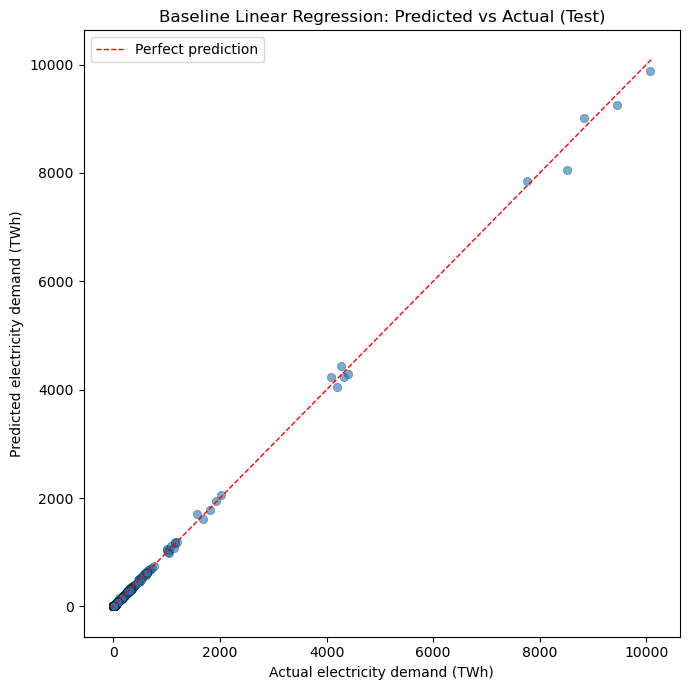

In [26]:
# Plot 1: Predicted vs Actual (Test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 50, max(y_test.max(), y_pred_test.max()) + 50]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('Baseline Linear Regression: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()

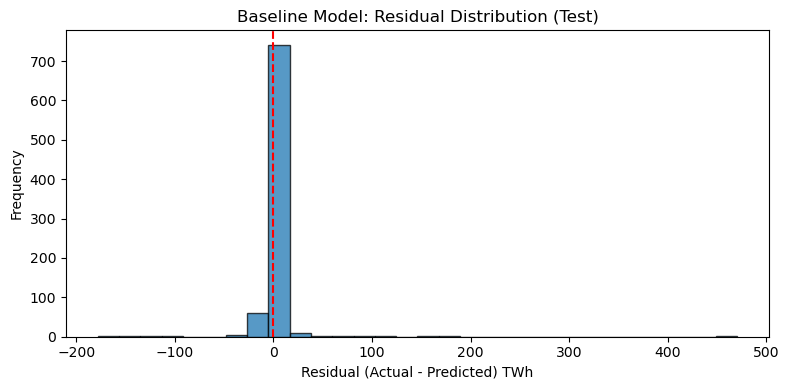

In [27]:
# Plot 2: Residual distribution
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.75)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('Baseline Model: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

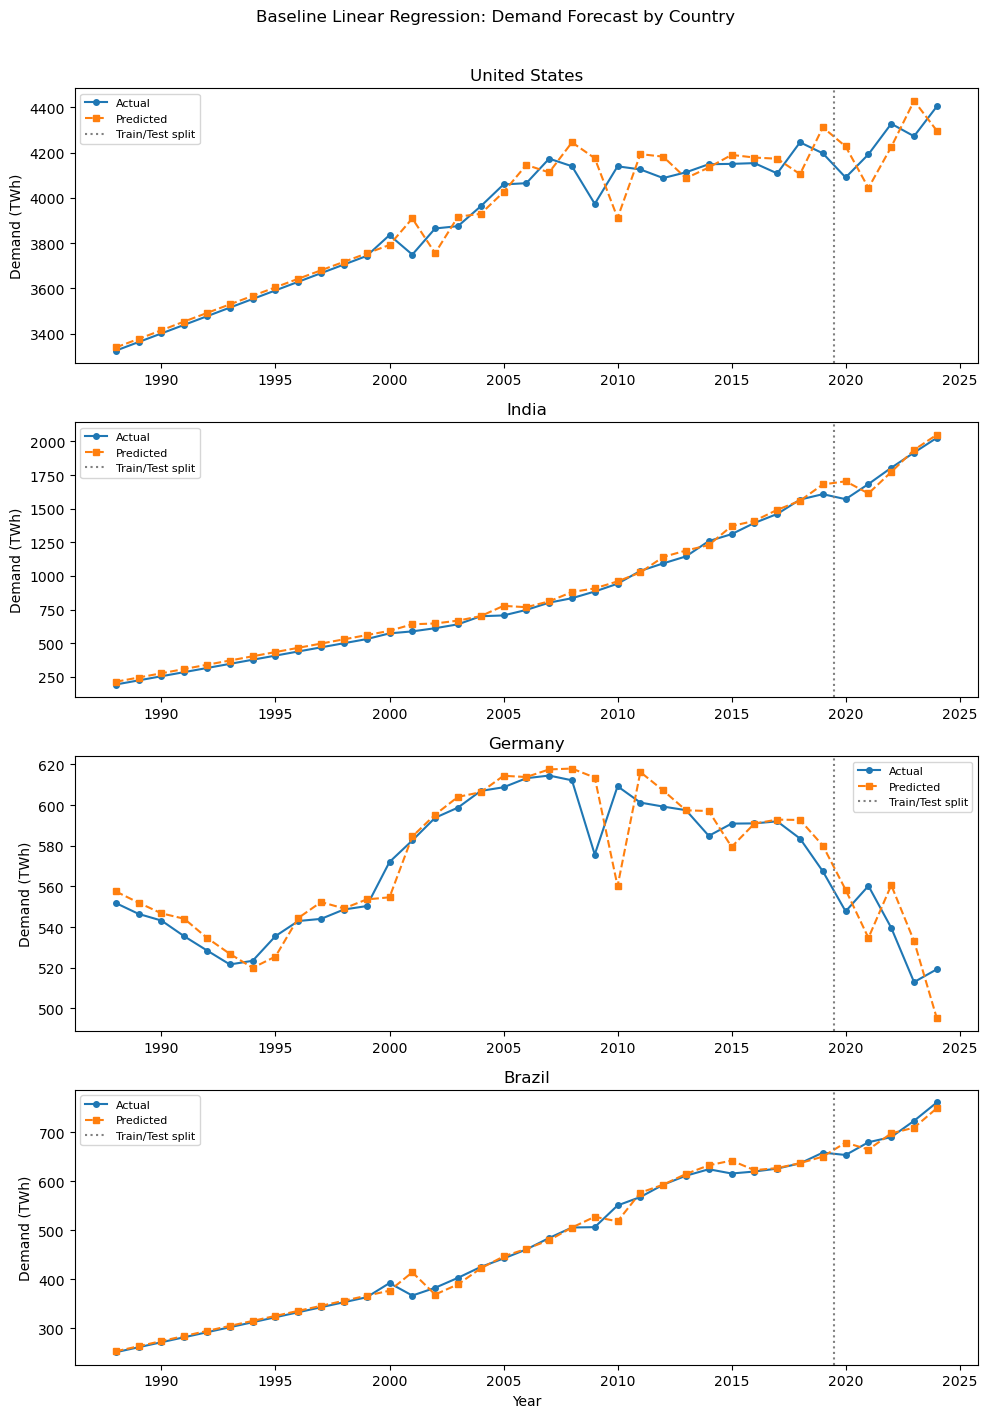

In [28]:
# Plot 3: Country-level overlays
preferred_countries = ['United States', 'India', 'Germany', 'Brazil']
available_countries = df_model['country'].unique()
sample_countries = [c for c in preferred_countries if c in available_countries]

# Fall back to top-4 countries by test RMSE if none of the defaults are present
if not sample_countries:
    sample_countries = country_metrics['country'].head(4).tolist()

fig, axes = plt.subplots(len(sample_countries), 1, figsize=(10, 3.5 * len(sample_countries)), sharex=False)
if len(sample_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, sample_countries):
    cdf = df_model[df_model['country'] == country].copy()
    cdf['predicted'] = model.predict(cdf[FEATURE_COLS])

    ax.plot(cdf['year'], cdf[TARGET], 'o-', label='Actual', markersize=4)
    ax.plot(cdf['year'], cdf['predicted'], 's--', label='Predicted', markersize=4)
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(country)
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Baseline Linear Regression: Demand Forecast by Country', y=1.01)
plt.tight_layout()
plt.show()


In [29]:
# Table of actual vs predicted for for all countries in test set
results_df = test[['country', 'year', TARGET]].copy()
results_df['predicted'] = y_pred_test
results_df.head(30)

,country,year,electricity_demand,predicted
35,American Samoa,2020,0.170000,-0.384189
36,American Samoa,2021,0.170000,-0.373982
37,American Samoa,2022,0.180000,-0.378096
38,American Samoa,2023,0.170000,-0.365637
74,Antigua and Barbuda,2020,0.350000,-0.106384
75,Antigua and Barbuda,2021,0.350000,-0.124975
76,Antigua and Barbuda,2022,0.360000,-0.123496
77,Antigua and Barbuda,2023,0.360000,-0.106258
113,Argentina,2020,149.350006,148.783981
114,Argentina,2021,155.649994,148.449459


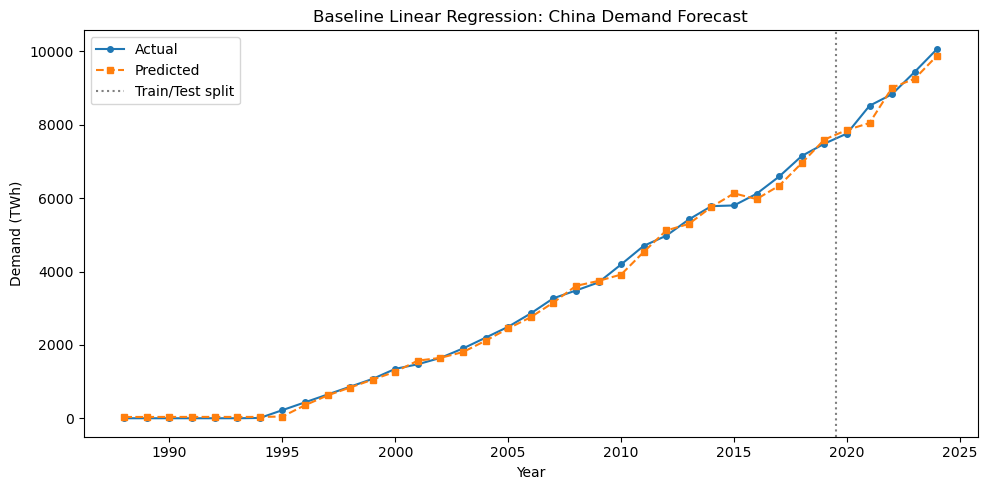

In [30]:
# Plot for one country (prefer China, fallback to available country)
preferred_country = 'China'
available_countries = set(df_model['country'].unique())

if preferred_country in available_countries:
    selected_country = preferred_country
elif len(available_countries) > 0:
    # Use highest-RMSE country from test metrics when preferred country is absent
    selected_country = country_metrics['country'].iloc[0] if len(country_metrics) > 0 else sorted(available_countries)[0]
else:
    selected_country = None

if selected_country is None:
    print('No countries available to plot.')
else:
    country_df = df_model[df_model['country'] == selected_country].copy()
    country_df['predicted'] = model.predict(country_df[FEATURE_COLS])

    plt.figure(figsize=(10, 5))
    plt.plot(country_df['year'], country_df[TARGET], 'o-', label='Actual', markersize=4)
    plt.plot(country_df['year'], country_df['predicted'], 's--', label='Predicted', markersize=4)
    plt.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    plt.title(f'Baseline Linear Regression: {selected_country} Demand Forecast')
    plt.xlabel('Year')
    plt.ylabel('Demand (TWh)')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation Notes

- This baseline is intentionally simple and interpretable.
- It should be compared directly against SARIMAX (same split and metrics).
- If SARIMAX cannot beat this baseline on Test RMSE/MAE, revisit feature engineering or SARIMAX specification.